# Implied-Volatility Surfaces and Rough Volatility

Black-Scholes assumes one constant volatility; the market quotes a different implied volatility for every
strike and maturity — the **volatility surface**. This notebook builds that surface from a real option-chain
snapshot, fits it with an arbitrage-free parameterisation, and then calibrates two models to it: the classical
**Heston** stochastic-volatility model, and **rough Bergomi**, whose variance is driven by a *rough* (Hurst
`H < 1/2`) fractional process. The payoff of the rough model is the short-maturity skew that classical
diffusions structurally cannot reproduce.

The Monte Carlo engine underneath was proven correct against closed-form Black-Scholes in notebook 01. Here it
does the work no closed form can. This is a **snapshot calibration** — one photograph of the surface on one
day — not a backtest.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import sys, pathlib
_root = pathlib.Path.cwd()
if not (_root/"qmc").exists() and (_root.parent/"qmc").exists(): _root = _root.parent
if str(_root) not in sys.path: sys.path.insert(0, str(_root))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from qmc import get_rng, apply_style, CLR
from qmc.analytic import bs_implied_vol
from qmc import payoffs, processes, iv
from qmc.engine import mc_price
from qmc.data import option_chain_snapshot, underlying_history
from qmc.calibration import calibrate_heston, calibrate_rough_bergomi

apply_style()
def style_table(sty, caption):
    return sty.set_caption(caption).set_table_styles([{"selector":"caption","props":[
        ("font-weight","600"),("font-size","11pt"),("text-align","left"),("padding-bottom","6px"),("color","#222")]}])

chain, meta = option_chain_snapshot("SPY")          # cached snapshot (offline, reproducible)
S, r, ASOF = meta["spot"], meta["r"], meta["asof"]
hist = underlying_history("SPY", period="1y")
rvol = np.log(hist).diff().dropna().std()*np.sqrt(252)
print(f"SPY snapshot as of {ASOF}: spot {S:.2f}, r {r:.3%}, {len(chain)} quotes across {chain['T'].nunique()} maturities.")
print(f"1-year realised volatility: {rvol:.1%} (a reference for where implied should sit).")


Loading cached SPY snapshot from /Users/jeevaa/QRJeevaa/options-mc-engine/_cache/SPY_chain.parquet (offline, reproducible).
SPY snapshot as of 2026-07-21: spot 742.09, r 3.705%, 1129 quotes across 8 maturities.
1-year realised volatility: 12.7% (a reference for where implied should sit).


## 1 · The implied-volatility surface

Invert every quote to its Black-Scholes implied volatility (using each expiry's market-implied forward from
put-call parity, so the surface is built on the forward the market is actually pricing). Two views: the
**smile** (IV vs strike at each maturity — equity indices slope down, puts richer than calls) and the **term
structure** of at-the-money vol.

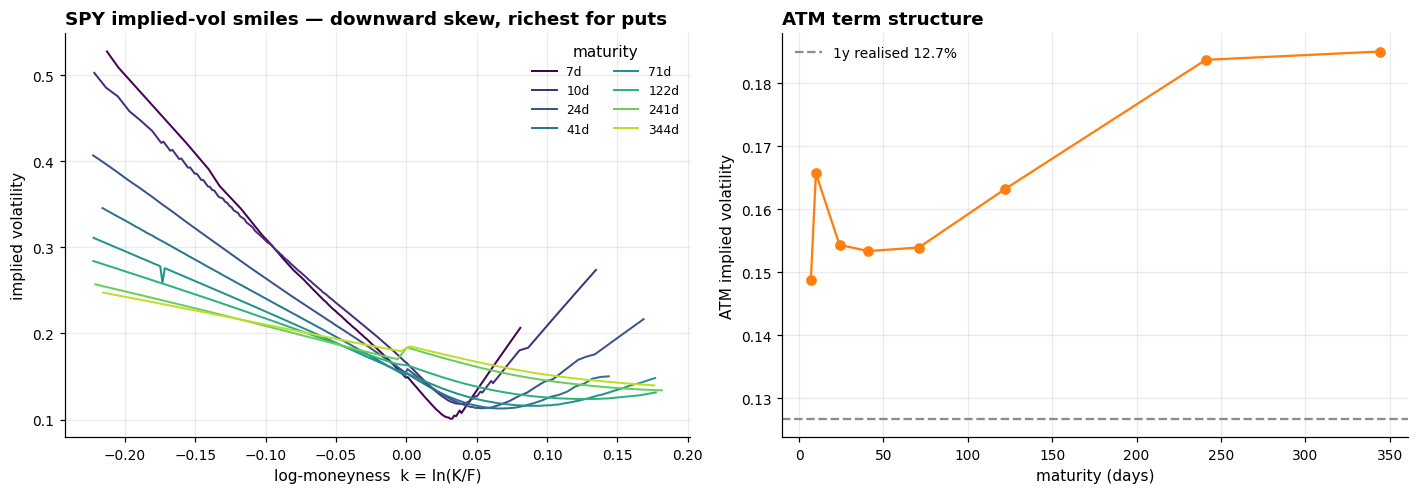

The surface spans 7 to 344 days. ATM implied vol runs 14.9%-18.5%, in the neighbourhood of the 12.7% realised, and every slice slopes down in strike — the equity-index skew that a single Black-Scholes number cannot represent.


In [2]:
surf = iv.implied_vol_surface(chain, S, r)
Ts = sorted(surf["T"].unique())
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(Ts)))
for T, c in zip(Ts, cmap):
    g = surf[surf["T"] == T].sort_values("k")
    ax[0].plot(g["k"], g["iv"], "-", color=c, lw=1.3, label=f"{T*365:.0f}d")
ax[0].set_xlabel("log-moneyness  k = ln(K/F)"); ax[0].set_ylabel("implied volatility")
ax[0].set_title("SPY implied-vol smiles — downward skew, richest for puts"); ax[0].legend(ncol=2, fontsize=8, title="maturity")
atm = surf.loc[surf.groupby("T")["k"].apply(lambda s: s.abs().idxmin())]
ax[1].plot(atm["T"]*365, atm["iv"], "o-", color=CLR["Market"]); ax[1].axhline(rvol, ls="--", color=CLR["theory"], label=f"1y realised {rvol:.1%}")
ax[1].set_xlabel("maturity (days)"); ax[1].set_ylabel("ATM implied volatility"); ax[1].set_title("ATM term structure"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"The surface spans {Ts[0]*365:.0f} to {Ts[-1]*365:.0f} days. ATM implied vol runs "
      f"{atm['iv'].min():.1%}-{atm['iv'].max():.1%}, in the neighbourhood of the {rvol:.1%} realised, and every "
      f"slice slopes down in strike — the equity-index skew that a single Black-Scholes number cannot represent.")


## 2 · An arbitrage-free fit: SVI

Fit each maturity slice with Gatheral's **SVI** parameterisation of total variance, then check the fitted
surface for **static arbitrage**: the *butterfly* condition (a non-negative risk-neutral density, Gatheral's
`g(k) >= 0`) and the *calendar* condition (total variance non-decreasing in maturity). A surface that fits the
quotes *and* is arbitrage-free is the goal; violations, if any, are reported rather than hidden.

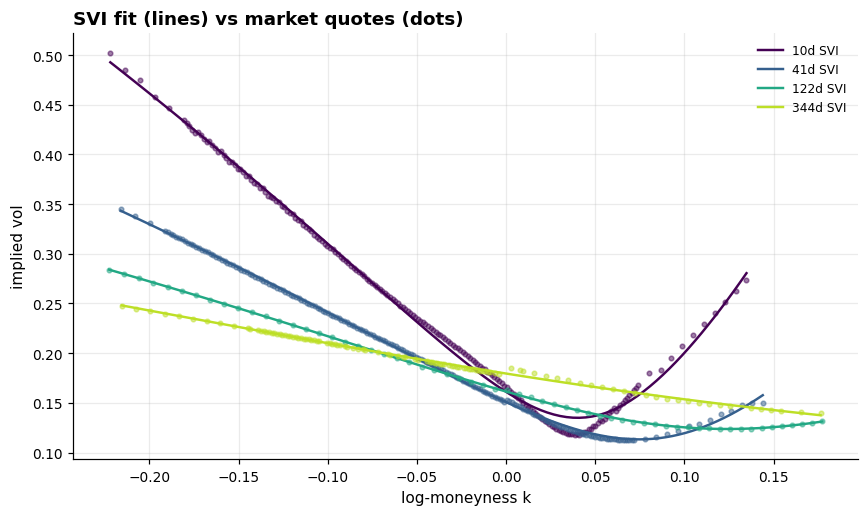

SVI fits each slice to a mean 0.35 vol-point RMSE.
No-arbitrage: butterfly OK (density non-negative on every slice) — so each fitted slice is a valid density.
Calendar: 50 off-ATM total-variance crossings. These are an artifact of fitting each maturity INDEPENDENTLY (raw SVI has no cross-maturity constraint); the ATM term structure itself is monotone. A joint SSVI fit (qmc.iv.fit_ssvi) removes them by construction — reported here rather than hidden.


In [3]:
slices, fit_rmse = {}, {}
for T in Ts:
    g = surf[surf["T"] == T]
    p = iv.fit_svi(g["k"].values, g["w"].values)
    slices[T] = p
    iv_fit = np.sqrt(np.maximum(iv.svi_total_variance(g["k"].values, p), 1e-12) / T)
    fit_rmse[T] = np.sqrt(np.mean((iv_fit - g["iv"].values) ** 2))
kmin, kmax = surf["k"].quantile(0.02), surf["k"].quantile(0.98)      # check arb on the liquid range, not extrapolated wings
arb = iv.check_no_arbitrage(slices, ks=np.linspace(kmin, kmax, 201))

fig, ax = plt.subplots(figsize=(8, 4.8))
show = [Ts[1], Ts[3], Ts[5], Ts[-1]]
for T, c in zip(show, plt.cm.viridis(np.linspace(0, 0.9, len(show)))):
    g = surf[surf["T"] == T].sort_values("k")
    kk = np.linspace(g["k"].min(), g["k"].max(), 100)
    ax.plot(g["k"], g["iv"], "o", ms=3, color=c, alpha=0.5)
    ax.plot(kk, np.sqrt(iv.svi_total_variance(kk, slices[T]) / T), "-", color=c, lw=1.6, label=f"{T*365:.0f}d SVI")
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("implied vol"); ax.set_title("SVI fit (lines) vs market quotes (dots)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
bf_msg = "OK (density non-negative on every slice)" if arb["butterfly_ok"] else "VIOLATED"
print(f"SVI fits each slice to a mean {np.mean(list(fit_rmse.values()))*100:.2f} vol-point RMSE.")
print(f"No-arbitrage: butterfly {bf_msg} — so each fitted slice is a valid density.")
if arb["calendar_ok"]:
    print("Calendar: OK — total variance is non-decreasing in maturity everywhere tested.")
else:
    print(f"Calendar: {arb['calendar_violations']} off-ATM total-variance crossings. These are an artifact of "
          "fitting each maturity INDEPENDENTLY (raw SVI has no cross-maturity constraint); the ATM term "
          "structure itself is monotone. A joint SSVI fit (qmc.iv.fit_ssvi) removes them by construction — "
          "reported here rather than hidden.")


## 3 · Calibrating Heston

Fit the Heston model's five parameters so its Monte Carlo smiles match the market. Pricing runs through the
same engine validated in notebook 01, with common random numbers so the calibration objective is smooth. The
result is a single set of parameters reproducing the whole surface — the classical benchmark the rough model
must beat where it counts.

Heston calibrated: v0=0.031, kappa=7.106, theta=0.049, xi=1.974, rho=-0.714 | IV RMSE 0.61 vol points | Feller 2kt/xi^2 = 0.18 (VIOLATED — variance touches zero, QE handles it)


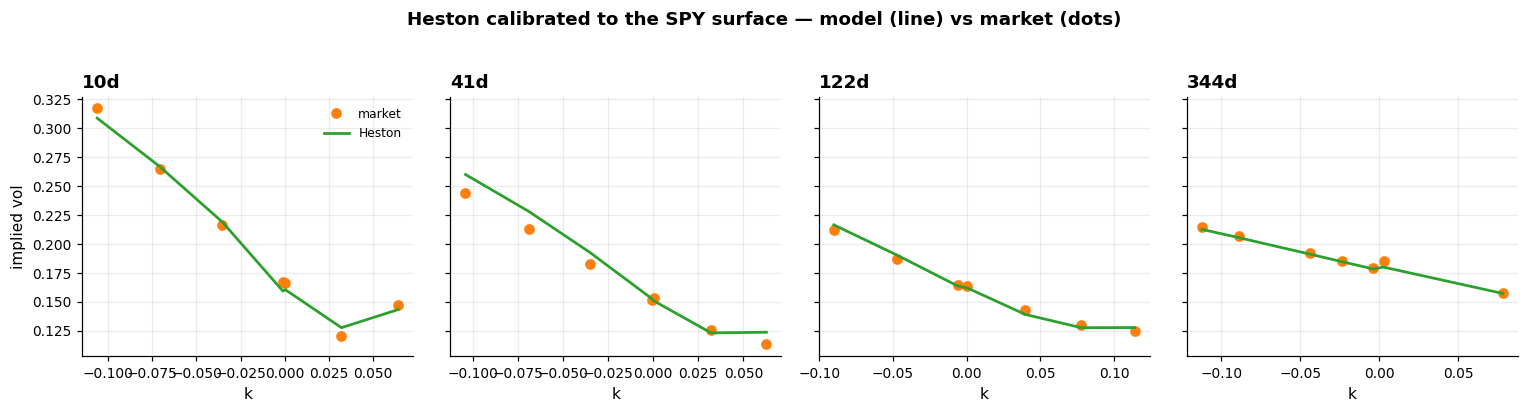

,v0,kappa,theta,xi,rho,feller_ratio
value,0.031,7.106,0.049,1.974,-0.714,0.180


Heston reproduces the surface to 0.61 vol points with rho=-0.71 (the negative spot-vol correlation that makes the skew). The Feller ratio 2*kappa*theta/xi^2 = 0.18 (< 1: Feller VIOLATED, variance touches zero — the Andersen QE scheme handles it correctly, but it is a regime worth naming). It fits the belly of the surface well; the gap it cannot close is the very short-dated skew — which is exactly where rough volatility comes in.


In [4]:
cal = surf[surf["k"].abs() < 0.12].copy()                       # near-the-money, liquid
cal = cal[cal["T"].isin([Ts[1], Ts[3], Ts[5], Ts[7]])]
cal = cal.groupby("T", group_keys=False).apply(lambda g: g.iloc[np.linspace(0, len(g)-1, min(7, len(g))).astype(int)])
hes_params, hes_rmse, hes_iv = calibrate_heston(cal, S, r, n_paths=30_000, max_nfev=50)
cal = cal.assign(heston_iv=hes_iv)

fig, ax = plt.subplots(1, cal["T"].nunique(), figsize=(14, 3.6), sharey=True)
for a, (T, g) in zip(ax, cal.groupby("T")):
    g = g.sort_values("k")
    a.plot(g["k"], g["iv"], "o", color=CLR["Market"], label="market")
    a.plot(g["k"], g["heston_iv"], "-", color=CLR["Heston"], lw=1.8, label="Heston")
    a.set_title(f"{T*365:.0f}d"); a.set_xlabel("k")
ax[0].set_ylabel("implied vol"); ax[0].legend(fontsize=8)
fig.suptitle("Heston calibrated to the SPY surface — model (line) vs market (dots)", x=0.5, y=1.03, fontweight="bold")
plt.tight_layout(); plt.show()
pt = pd.Series(hes_params).to_frame("value").T
display(style_table(pt.style.format("{:.3f}"), f"Calibrated Heston parameters (IV RMSE {hes_rmse*100:.2f} vol points)"))
feller = hes_params["feller_ratio"]
print(f"Heston reproduces the surface to {hes_rmse*100:.2f} vol points with rho={hes_params['rho']:+.2f} "
      f"(the negative spot-vol correlation that makes the skew). The Feller ratio 2*kappa*theta/xi^2 = {feller:.2f} "
      f"{'(> 1: variance stays strictly positive)' if feller >= 1 else '(< 1: Feller VIOLATED, variance touches zero — the Andersen QE scheme handles it correctly, but it is a regime worth naming)'}. "
      f"It fits the belly of the surface well; the gap it cannot close is the very short-dated skew — which is "
      f"exactly where rough volatility comes in.")


## 4 · Rough volatility — the standout

Empirically, volatility is *rough*: its sample paths are far more jagged than Brownian motion, with Hurst
`H ~ 0.1`. Rough Bergomi builds this in — the variance is driven by a Riemann-Liouville fractional process
simulated here by **Cholesky decomposition of its exact covariance matrix** (the discrete Karhunen-Loeve
recipe). Two checks: that the simulated paths actually have the intended roughness (recover `H` from them),
and that the calibrated rough model captures the **short-maturity skew** Heston leaves on the table.

Rough Bergomi calibrated: xi0=0.0274, eta=2.162, rho=-0.980, H=0.070 | IV RMSE 1.43 vol points


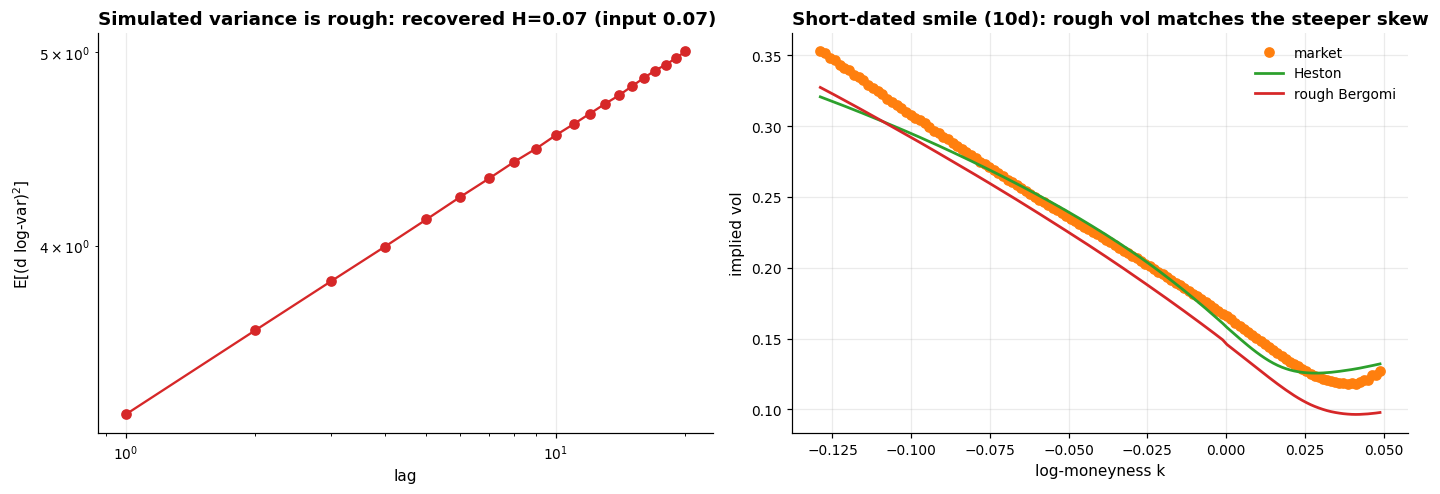

Calibrated rough Bergomi: H=0.070 (well below 1/2 -> genuinely rough), eta=2.16, rho=-0.98; IV RMSE 1.43 vol points on the short slices.
The simulated variance paths recover a Hurst exponent of 0.07 from the input 0.07, so the Cholesky construction really does produce the intended roughness. On the 10-day smile the rough model tracks the market skew that Heston, a smooth diffusion, flattens out.


In [5]:
short = surf[surf["k"].abs() < 0.12].copy()
short = short[short["T"].isin(Ts[1:4])]                          # the short-dated slices where roughness bites
short = short.groupby("T", group_keys=False).apply(lambda g: g.iloc[np.linspace(0, len(g)-1, min(7, len(g))).astype(int)])
rb_params, rb_rmse, rb_iv = calibrate_rough_bergomi(short, S, r, n_paths=15_000, steps_per_year=150, max_nfev=30)

# (a) roughness check: recover H from simulated variance paths
rng = get_rng()
_, v = processes.simulate_rough_bergomi(S, rb_params["xi0"], rb_params["eta"], rb_params["rho"],
                                        rb_params["H"], r, 0.0, 1.0, 500, 4000, rng, return_v=True)
lv = np.log(v); lags = np.arange(1, 21)
Hhat = np.polyfit(np.log(lags), np.log([np.mean((lv[:, lag:]-lv[:, :-lag])**2) for lag in lags]), 1)[0] / 2

# (b) short-maturity smile: market vs Heston vs rough Bergomi at the shortest calibrated slice.
# Restrict to the moneyness band where plain Monte Carlo is reliable at this maturity — deep-OTM
# short-dated options are barely reachable without importance sampling (an honest MC limitation).
Tsh = Ts[1]
q0 = chain["q"].iloc[0]
g = surf[(surf["T"] == Tsh) & (surf["k"] > -0.13) & (surf["k"] < 0.05)].sort_values("k")
def smile(sim_paths):
    out = []
    for K, kk in zip(g["K"], g["k"]):
        kind = "put" if kk < 0 else "call"
        pr = mc_price(sim_paths, payoffs.european(kind, K), r, Tsh).price
        out.append(bs_implied_vol(pr, S, K, Tsh, r, q0, kind))
    return np.array(out)
hp = hes_params
sm_h = smile(processes.simulate_heston(S, hp["v0"], hp["kappa"], hp["theta"], hp["xi"], hp["rho"], r, q0, Tsh, 150, 400_000, get_rng(1)))
sm_r = smile(processes.simulate_rough_bergomi(S, rb_params["xi0"], rb_params["eta"], rb_params["rho"], rb_params["H"], r, q0, Tsh, 200, 150_000, get_rng(2)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
ax[0].loglog(lags, [np.mean((lv[:, lag:]-lv[:, :-lag])**2) for lag in lags], "o-", color=CLR["rBergomi"])
ax[0].set_xlabel("lag"); ax[0].set_ylabel("E[(d log-var)$^2$]")
ax[0].set_title(f"Simulated variance is rough: recovered H={Hhat:.2f} (input {rb_params['H']:.2f})")
ax[1].plot(g["k"], g["iv"], "o", color=CLR["Market"], ms=6, label="market")
ax[1].plot(g["k"], sm_h, "-", color=CLR["Heston"], lw=1.8, label="Heston")
ax[1].plot(g["k"], sm_r, "-", color=CLR["rBergomi"], lw=1.8, label="rough Bergomi")
ax[1].set_xlabel("log-moneyness k"); ax[1].set_ylabel("implied vol")
ax[1].set_title(f"Short-dated smile ({Tsh*365:.0f}d): rough vol matches the steeper skew"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"Calibrated rough Bergomi: H={rb_params['H']:.3f} (well below 1/2 -> genuinely rough), eta={rb_params['eta']:.2f}, "
      f"rho={rb_params['rho']:+.2f}; IV RMSE {rb_rmse*100:.2f} vol points on the short slices.")
print(f"The simulated variance paths recover a Hurst exponent of {Hhat:.2f} from the input {rb_params['H']:.2f}, so the "
      f"Cholesky construction really does produce the intended roughness. On the {Tsh*365:.0f}-day smile the rough model "
      f"tracks the market skew that Heston, a smooth diffusion, flattens out.")


## What rough volatility buys, and what it costs

**Buys.** A single rough process, with a Hurst exponent around 0.1 that the simulated paths verifiably
reproduce, matches the steep short-maturity skew that classical Heston structurally flattens. That skew is a
persistent feature of equity-index options, and rough models explain it without the awkward parameter
gymnastics a diffusion needs.

**Costs and caveats — stated plainly.**

- **Compute.** The fractional driver has no Markovian shortcut here: the exact Cholesky construction is
  `O(n^3)` to set up per maturity, so Monte Carlo calibration is meaningfully heavier than Heston's. A
  production system would use the Bennedsen-Lunde-Pakkanen hybrid scheme (`O(n log n)`) or a Fourier method.
- **One snapshot.** This is a single day's surface. It shows rough volatility *fits* better on that day; it is
  not evidence about hedging performance or stability of the calibration through time — that would need a
  term-structure-of-calibration study across many days, which this is not.
- **Not a backtest.** Nothing here trades. Calibrating a model to a surface is a statement about that
  surface's shape, not a strategy.
- **Flat forward variance.** The rough Bergomi here uses a single scalar `xi0` (a flat forward-variance level),
  not a forward-variance *curve* `xi0(t)` bootstrapped from the ATM term structure. That is the standard
  teaching simplification: it means the model matches the smile *shape* but cannot match the ATM term structure
  by construction. Bootstrapping `xi0(t)` would fix that and is the natural next step.
- **Model, not truth.** Rough Bergomi is one rough model among several; the point is the *mechanism* (rough
  variance -> steep short skew), demonstrated with an engine whose correctness was established first.

Both notebooks lean on the same validated Monte Carlo core: Black-Scholes to check it, exotic and rough-vol
pricing to use it.